In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmdline_provenance as cmdprov

from unseen import fileio
from unseen import array_handling
from unseen import general_utils

In [21]:
code_url = 'https://github.com/AusClimateService/unseen-projects/tree/master/project-wcrp-txx'
outdir = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data'
model = 'NorCPM1'

In [3]:
infile_dict = {}
infile_dict['tasmax'] = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax-june-july_NorCPM1-dcppA-hindcast_196010-201810_annual_north-america.nc'
infile_dict['psl'] = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl-june-july_NorCPM1-dcppA-hindcast_196010-201810_annual_north-america.nc'

In [4]:
ds_dict = {}
ds_dict['tasmax'] = fileio.open_dataset(infile_dict['tasmax'])
ds_dict['psl'] = fileio.open_dataset(infile_dict['psl'])

In [5]:
units_dict = {}
units_dict['tasmax'] = 'degC'
units_dict['psl'] = 'hPa'

In [6]:
def calc_clim(ds, var):
    """Calculate climatology"""

    ds = ds.compute()
    ds[var] = general_utils.convert_units(ds[var], units_dict[var])
    ds = array_handling.reindex_forecast(ds)
    da_baseline = ds[var].sel(time=slice('1991-01-01', '2020-12-31'))
    da_clim = da_baseline.mean(dim=['time', 'init_date', 'ensemble'])

    return da_clim

In [7]:
clim_dict = {}
clim_dict['tasmax'] = calc_clim(ds_dict['tasmax'], 'tasmax')
clim_dict['psl'] = calc_clim(ds_dict['psl'], 'psl')

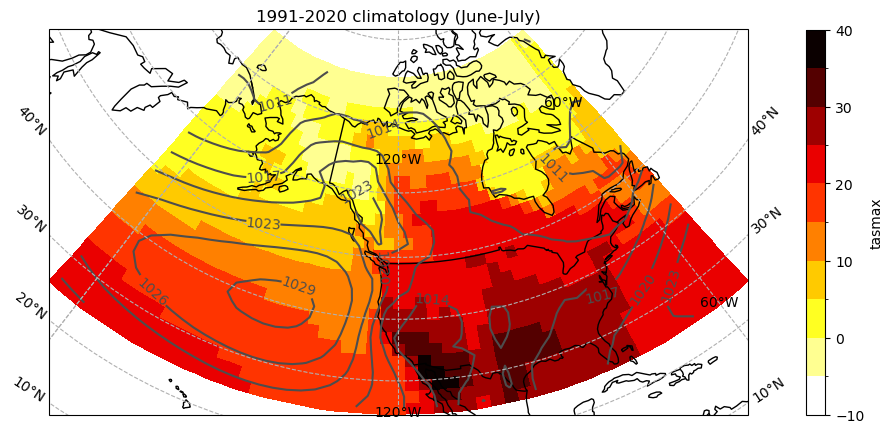

In [9]:
map_proj = ccrs.LambertConformal(
    central_longitude=240,
    central_latitude=50,
)

fig = plt.figure(figsize=[15, 5])
ax = fig.add_subplot(111, projection=map_proj)

clim_dict['tasmax'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='hot_r',
    levels=np.arange(-10, 45, 5),
#    extend='both',
    #    cbar_kwargs={"label": label},
)
lines = clim_dict['psl'].plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=np.arange(900, 1100, 3),
    colors=["0.3"]
)
ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.gridlines(linestyle="--", draw_labels=True)

plt.title('1991-2020 climatology (June-July)')
plt.show()

In [28]:
def add_attrs(da_clim, var, unit):
    """Add file attributes"""

    ds = da_clim.to_dataset()
    orig_ds = ds_dict[var]
    
    ds[var].attrs['long_name'] = orig_ds[var].attrs['long_name']
    ds[var].attrs['standard_name'] = orig_ds[var].attrs['standard_name']
    ds[var].attrs['units'] = units_dict[var]

    ds.attrs = {
        'description': '1991-2020 climatology (June-July)',
        'model': model,
        'history': cmdprov.new_log(code_url=code_url),
    }

    return ds

In [29]:
def get_encoding(ds, var):
    """Output file encoding."""

    encoding = {}
    ds_vars = list(ds.coords) + list(ds.keys())
    for ds_var in ds_vars:
        encoding[ds_var] = {'_FillValue': None}

    return encoding

In [30]:
def get_outfname(inpath):
    """Get output file name."""

    infname = inpath.split('/')[-1]
    fparts = infname.split('_')
    fparts[-3] = '1991-2020'
    fparts[-2] = 'climatology'
    outfname = '_'.join(fparts)
    outpath = f'{outdir}/{outfname}'

    return outpath

In [31]:
for var in ['tasmax', 'psl']:
    output_ds = add_attrs(clim_dict[var], var, units_dict[var])
    fname = get_outfname(infile_dict[var])
    encoding = get_encoding(output_ds, var)
    output_ds.to_netcdf(fname, encoding=encoding)
    print(fname)

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax-june-july_NorCPM1-dcppA-hindcast_1991-2020_climatology_north-america.nc
/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/psl-june-july_NorCPM1-dcppA-hindcast_1991-2020_climatology_north-america.nc
